<a href="https://colab.research.google.com/github/andy1680303/machine_learnig_project_2/blob/main/%E7%AC%AC%E4%B8%89%E7%B5%84%E6%9C%9F%E6%9C%AB%E5%A0%B1%E5%91%8A%E7%A8%8B%E5%BC%8F%E7%A2%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#匯入資料

In [ ]:
import pandas as pd
#讀取料庫
df = pd.read_csv('/content/complete_countries_2010_2019.csv')

# 4. 定義自變項（X）與依變項（Y）清單，方便後續重複呼叫
#注意這裡的y是BOTH
y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]

# 預覽資料前五列
print(f"資料集規模：{df.shape[0]} 列, {df.shape[1]} 個欄位")
df[['Entity', 'Year', y_var] + x_vars].head()

資料集規模：1290 列, 12 個欄位


,Entity,Year,both_rate_val,PM2_5_air_pollution__mean_annua,clean_e,GDP_per_capita,Urban_population_of_total_pop,Annual_Mean_Temperature,Current_health_expenditure_CHE_
0,Afghanistan,2010,10305.068710,49.679380,19.8,2848.5862,22.261480,13.415829,8.56967
1,Afghanistan,2011,10098.619610,61.817055,21.3,2757.0525,22.820570,13.000890,8.56191
2,Afghanistan,2012,9901.769666,70.922320,22.9,2985.3190,23.343440,11.628624,7.89717
3,Afghanistan,2013,9707.807026,73.131810,24.4,3046.5798,23.807714,12.842954,8.80596
4,Afghanistan,2014,9452.655446,77.143730,25.8,3017.9426,24.191017,12.295892,9.52888


#常態性檢定

 兒童呼吸道疾病發病率 常態性檢定結果 
Skewness: 0.7168  (>0 代表數據右偏/長尾在右)
Excess Kurtosis: -0.1496  (>0 代表分佈較陡峭/高尖)
D'Agostino's K-squared 檢定結果: 統計量 = 92.4805, p-value = 8.2814e-21
Kolmogorov-Smirnov 檢定結果: 統計量 = 0.0995, p-value = 1.3995e-11
若 p-value < 0.05，代表在統計學上顯著拒絕常態分佈假設。


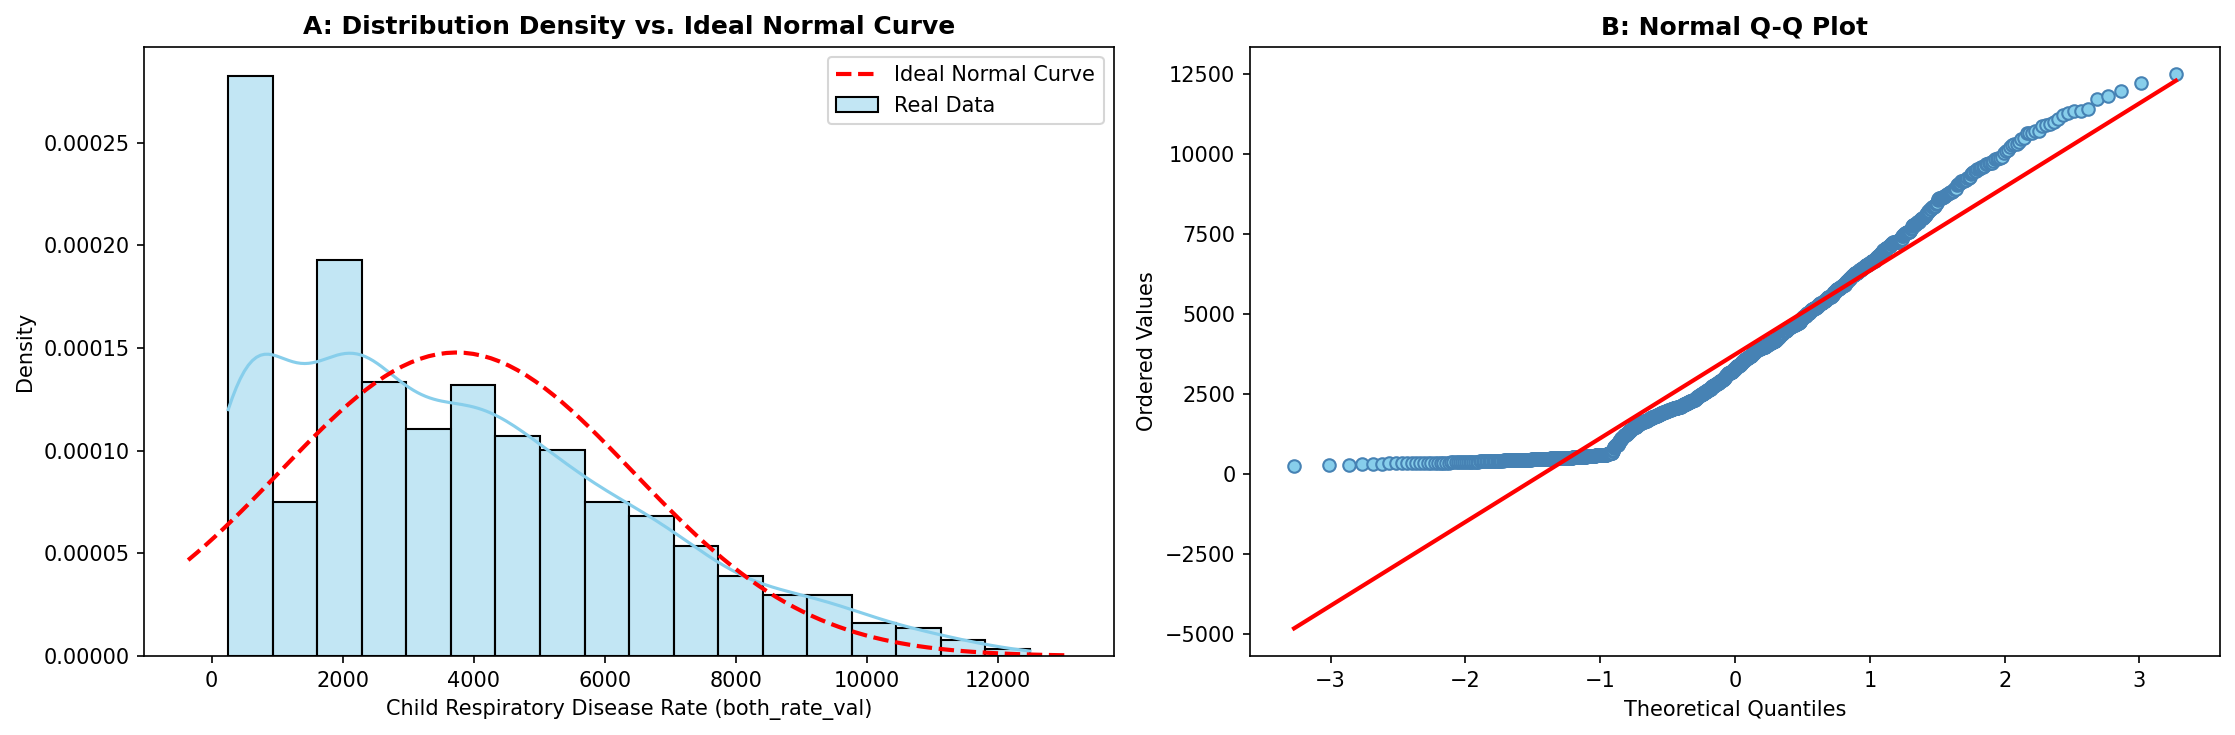

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#1.讀取與整理數據
df = pd.read_csv('complete_countries_2010_2019.csv')
y_var = 'both_rate_val'
df_clean = df.dropna(subset=[y_var]).reset_index(drop=True)

print(" 兒童呼吸道疾病發病率 常態性檢定結果 ")

# 2. 計算偏度 (Skewness) 與 峰度 (Kurtosis)
# 理想常態分佈的偏度應接近 0，峰度接近 3 (或超額峰度接近 0)
data_skew = stats.skew(df_clean[y_var])
data_kurt = stats.kurtosis(df_clean[y_var], fisher=True) # fisher=True 代表超額峰度，0為常態

print(f"Skewness: {data_skew:.4f}  (>0 代表數據右偏/長尾在右)")
print(f"Excess Kurtosis: {data_kurt:.4f}  (>0 代表分佈較陡峭/高尖)")

# 3. 執行統計檢定 (由於 N=1290 較大，使用 D'Agostino's K-squared 檢定與 KS 檢定，不使用 Shapiro-Wilk)
# D'Agostino's 檢定結合了偏度與峰度的測試
k2_stat, k2_p = stats.normaltest(df_clean[y_var])
print(f"D'Agostino's K-squared 檢定結果: 統計量 = {k2_stat:.4f}, p-value = {k2_p:.4e}")

# Kolmogorov-Smirnov 檢定 (與標準化後的數據對比)
std_data = (df_clean[y_var] - df_clean[y_var].mean()) / df_clean[y_var].std()
ks_stat, ks_p = stats.kstest(std_data, 'norm')
print(f"Kolmogorov-Smirnov 檢定結果: 統計量 = {ks_stat:.4f}, p-value = {ks_p:.4e}")

print("若 p-value < 0.05，代表在統計學上顯著拒絕常態分佈假設。")

# 4.繪圖
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

# 左圖：發病率直方圖 + 核密度估計曲線 (KDE) + 理想常態曲線對比
sns.histplot(df_clean[y_var], kde=True, stat="density", color="skyblue", ax=ax1, label='Real Data')
# 繪常態分佈的虛線
mu, std = df_clean[y_var].mean(), df_clean[y_var].std()
xmin, xmax = ax1.get_xlim()
x_axis = np.linspace(xmin, xmax, 100)
ax1.plot(x_axis, stats.norm.pdf(x_axis, mu, std), 'r--', linewidth=2, label='Ideal Normal Curve')
ax1.set_title("A: Distribution Density vs. Ideal Normal Curve", fontsize=12, fontweight='bold')
ax1.set_xlabel("Child Respiratory Disease Rate (both_rate_val)", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.legend()

# 右圖：Q-Q 圖 (Quantile-Quantile Plot)
stats.probplot(df_clean[y_var], dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('skyblue')
ax2.get_lines()[0].set_markeredgecolor('steelblue')
ax2.get_lines()[1].set_color('red')
ax2.get_lines()[1].set_linewidth(2)
ax2.set_title("B: Normal Q-Q Plot", fontsize=12, fontweight='bold')
ax2.set_xlabel("Theoretical Quantiles", fontsize=10)
ax2.set_ylabel("Ordered Values", fontsize=10)

plt.tight_layout()
plt.show()

##常態性檢定結果→資料呈現非常態性分布

因此接下來使用spearman相關性檢定

#相關性分析

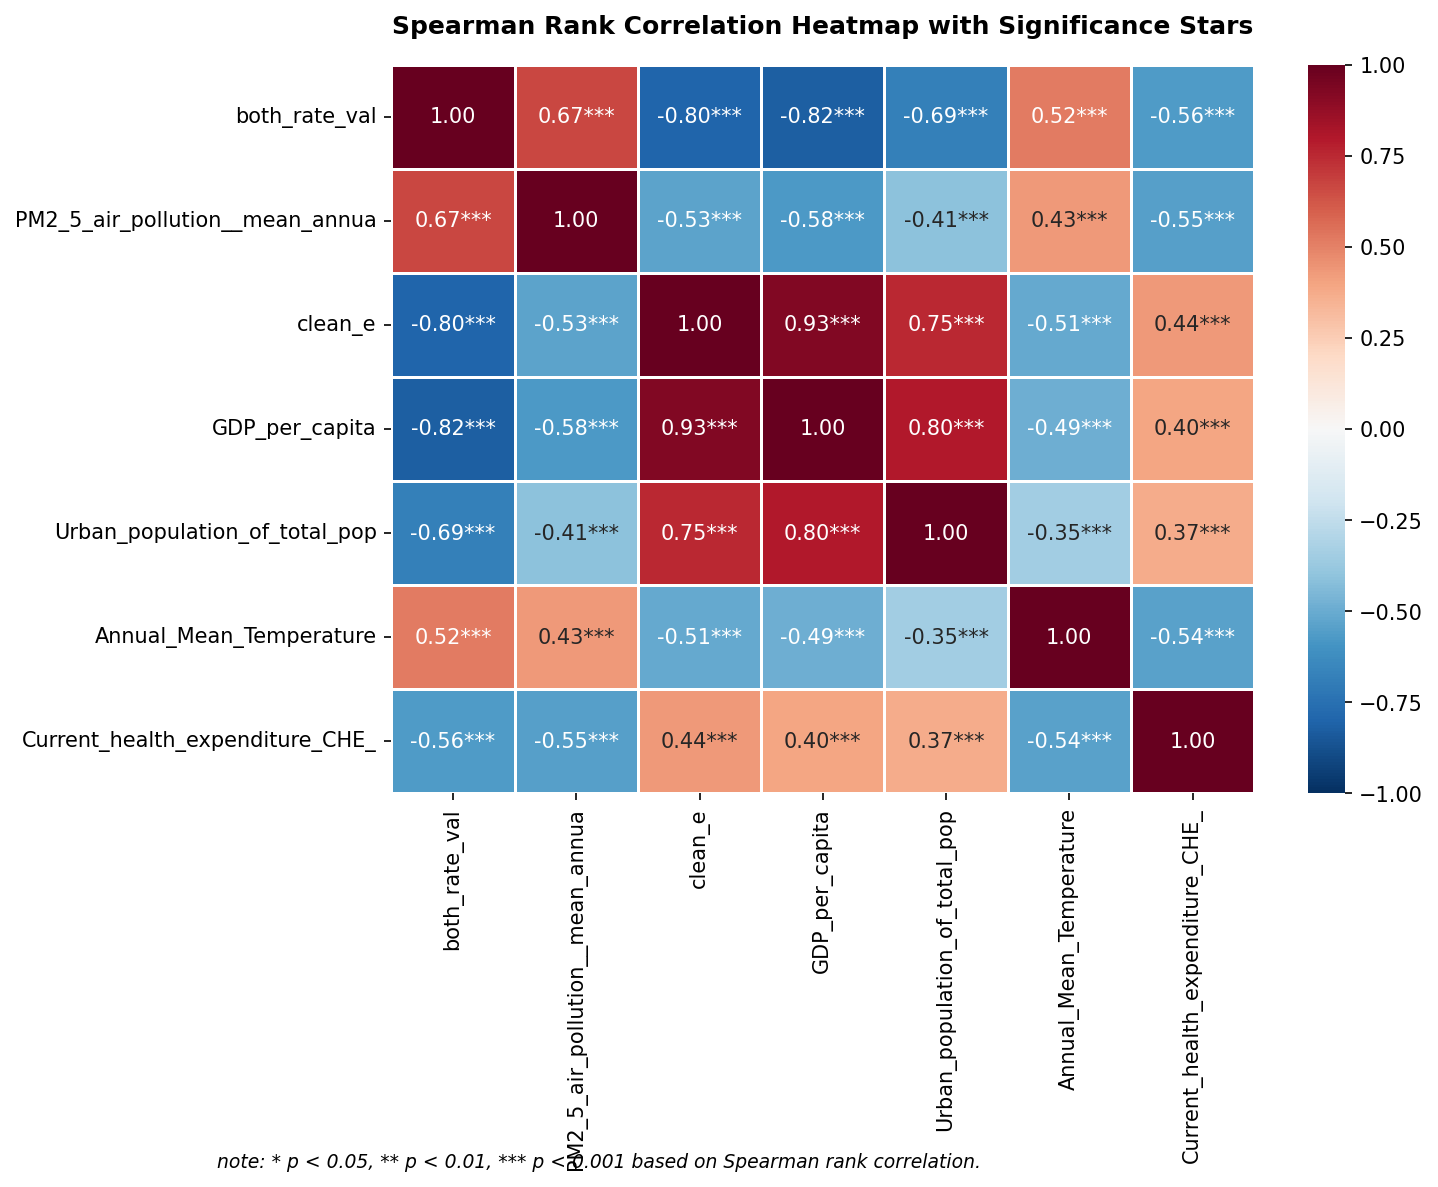

In [ ]:
#加上p值星號
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. 讀取與安全清洗數據
df = pd.read_csv('complete_countries_2010_2019.csv')
y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]
df_clean = df.dropna(subset=[y_var] + x_vars).reset_index(drop=True)
all_vars = [y_var] + x_vars

# 2. 同時計算 Spearman 相關係數與 p 值矩陣
cols = len(all_vars)
corr_matrix = np.zeros((cols, cols))
p_matrix = np.zeros((cols, cols))
labels_matrix = np.empty((cols, cols), dtype=object)

for i in range(cols):
    for j in range(cols):
        # 計算兩兩變項間的 Spearman 等級相關
        r, p = stats.spearmanr(df_clean[all_vars[i]], df_clean[all_vars[j]])
        corr_matrix[i, j] = r
        p_matrix[i, j] = p

        # 根據 p 值大小給予星號標註
        if p < 0.001:
            stars = "***"
        elif p < 0.01:
            stars = "**"
        elif p < 0.05:
            stars = "*"
        else:
            stars = "" # 不顯著

        # 對角線是變項自己跟自己，不需要打星號
        if i == j:
            labels_matrix[i, j] = f"{r:.2f}"
        else:
            labels_matrix[i, j] = f"{r:.2f}{stars}"

# 3. 轉成 DataFrame 方便設定圖表標籤
corr_df = pd.DataFrame(corr_matrix, index=all_vars, columns=all_vars)

# 4. 繪製有顯著性星號的圖
plt.figure(figsize=(10, 8), dpi=150)
sns.heatmap(
    corr_df,
    annot=labels_matrix,  # 將「係數+星號」的矩陣丟進去顯示
    fmt="",        # 字串格式，維持原本文字不變
    cmap='RdBu_r',    # 紅（正相關）藍（負相關）
    linewidths=0.5,
    vmax=1, vmin=-1
)

plt.title('Spearman Rank Correlation Heatmap with Significance Stars', fontsize=12, pad=15, fontweight='bold')
#加註統計註解
plt.figtext(0.15, 0.02, "note: * p < 0.05, ** p < 0.01, *** p < 0.001 based on Spearman rank correlation.", fontsize=9, style='italic')
plt.tight_layout()
plt.show()
plt.close()

#檢查共線性

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# 計算 VIF
vif_df = df[x_vars].dropna().copy()

# 加上截距項 (Constant) 是計算 VIF 的標準統計步驟
vif_df['Intercept'] = 1

#計算每個變項間的 VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = x_vars
vif_data["VIF"] = [variance_inflation_factor(vif_df.values, i) for i in range(len(x_vars))]

print("=== 變異數膨脹因子 (VIF) 檢定結果 ===")
display(vif_data.round(2))

=== 變異數膨脹因子 (VIF) 檢定結果 ===


,Variable,VIF
0,PM2_5_air_pollution__mean_annua,1.42
1,clean_e,2.78
2,GDP_per_capita,2.20
3,Urban_population_of_total_pop,2.69
4,Annual_Mean_Temperature,1.72
5,Current_health_expenditure_CHE_,1.60


#描述性統計

In [ ]:
#描述性統計
table_1 = df[[y_var] + x_vars].describe().T
table_1 = table_1[['mean', 'std', 'min','25%','50%','75%',  'max']]
table_1.columns = ['平均數 (Mean)', '標準差 (SD)','最小值 (Min)', '第一四分位數 (Q1)','中位數 (Median)','第三四分位數 (Q3)',  '最大值 (Max)']

print("Table 1: 變項描述性統計")
display(table_1.round(2))

Table 1: 變項描述性統計


,平均數 (Mean),標準差 (SD),最小值 (Min),第一四分位數 (Q1),中位數 (Median),第三四分位數 (Q3),最大值 (Max)
both_rate_val,3736.69,2698.45,253.61,1643.88,3303.33,5435.25,12492.78
PM2_5_air_pollution__mean_annua,27.43,18.64,5.13,14.27,21.49,32.83,107.14
clean_e,66.86,37.72,0.15,31.40,87.05,100.00,100.00
GDP_per_capita,23275.75,23998.68,991.04,5300.44,14058.47,33714.32,145590.77
Urban_population_of_total_pop,58.05,22.17,10.98,41.24,59.30,75.65,100.00
Annual_Mean_Temperature,18.45,8.29,-4.21,10.83,21.80,25.42,29.78
Current_health_expenditure_CHE_,6.28,2.53,1.60,4.27,6.07,8.15,21.97


#廣義估計方程式(GEE)

##暴露濃度不分組

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 定義所有要納入模型的變項
y_var = 'both_rate_val'
x_vars_continuous = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]

# 2. 安全剔除缺失值並建立獨立副本，防止 SettingWithCopyWarning
df_clean_continuous = df.dropna(subset=[y_var] + x_vars_continuous).copy()

# 3. 建立年份類別變項
df_clean_continuous['Year_Factor'] = df_clean_continuous['Year'].astype(str)

# 4. 將資料依照國家 (Entity) 與 年份 (Year) 嚴格排序
df_gee_continuous = df_clean_continuous.sort_values(by=['Entity', 'Year']).reset_index(drop=True)

# 5. 定義連續型迴歸公式
formula_continuous = """both_rate_val ~
    PM2_5_air_pollution__mean_annua +
    clean_e +
    GDP_per_capita +
    Urban_population_of_total_pop +
    Annual_Mean_Temperature +
    Current_health_expenditure_CHE_ +
    C(Year_Factor)"""

# 6. 建立與擬合 GEE 模型 (AR-1 自迴歸結構)
gee_model_cont = smf.gee(
    formula=formula_continuous,
    groups=df_gee_continuous['Entity'],
    data=df_gee_continuous,
    time=df_gee_continuous['Year'],
    cov_struct=sm.cov_struct.Autoregressive(
        1,
        lambda x1, x2: np.abs(x1 - x2)
    )
)
gee_results_cont = gee_model_cont.fit()


print("結果")

print(gee_results_cont.summary())

結果
                               GEE Regression Results                              
Dep. Variable:               both_rate_val   No. Observations:                 1290
Model:                                 GEE   No. clusters:                      129
Method:                        Generalized   Min. cluster size:                  10
                      Estimating Equations   Max. cluster size:                  10
Family:                           Gaussian   Mean cluster size:                10.0
Dependence structure:       Autoregressive   Num. iterations:                    60
Date:                     Mon, 08 Jun 2026   Scale:                     2807773.685
Covariance type:                    robust   Time:                         15:17:39
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                        9141.909

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


##暴露濃度分組

In [ ]:
# 1.根據依常見政策劃分 <15ug/m3, 15~35ug/m3, >35ug/m3
def categorize_pm(val):
    if val <= 15:
        return '0_Low (<=15)'   # 基準對照組
    elif val <= 35:
        return '1_Medium (15-35)'
    else:
        return '2_High (>35)'

# 2. 安全建立獨立副本並應用分組
df_clean_group = df.dropna(subset=['both_rate_val', 'PM2_5_air_pollution__mean_annua', 'clean_e', 'GDP_per_capita', 'Urban_population_of_total_pop', 'Annual_Mean_Temperature', 'Current_health_expenditure_CHE_']).copy()
df_clean_group['PM25_Group'] = df_clean_group['PM2_5_air_pollution__mean_annua'].apply(categorize_pm)
df_clean_group['Year_Factor'] = df_clean_group['Year'].astype(str)

# 3. 依照國家與年份進行嚴格排序
df_gee_group = df_clean_group.sort_values(by=['Entity', 'Year']).reset_index(drop=True)

# 4. 定義分組型迴歸公式
formula_group = """both_rate_val ~
    C(PM25_Group) +
    clean_e +
    GDP_per_capita +
    Urban_population_of_total_pop +
    Annual_Mean_Temperature +
    Current_health_expenditure_CHE_ +
    C(Year_Factor)"""

# 5. 建立與擬合分組 GEE 模型
gee_model_grp = smf.gee(
    formula=formula_group,
    groups=df_gee_group['Entity'],
    data=df_gee_group,
    time=df_gee_group['Year'],
    cov_struct=sm.cov_struct.Autoregressive(
        1,
        lambda x1, x2: np.abs(x1 - x2)
    )
)
gee_results_grp = gee_model_grp.fit()

print("結果")

print(gee_results_grp.summary())

結果
                               GEE Regression Results                              
Dep. Variable:               both_rate_val   No. Observations:                 1290
Model:                                 GEE   No. clusters:                      129
Method:                        Generalized   Min. cluster size:                  10
                      Estimating Equations   Max. cluster size:                  10
Family:                           Gaussian   Mean cluster size:                10.0
Dependence structure:       Autoregressive   Num. iterations:                    54
Date:                     Mon, 08 Jun 2026   Scale:                     2888030.441
Covariance type:                    robust   Time:                         15:17:49
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                          92

#機器學習

##隨機森林

訓練集 R^2 : 0.994 | 測試集 R^2 : 0.937

SHAP 值


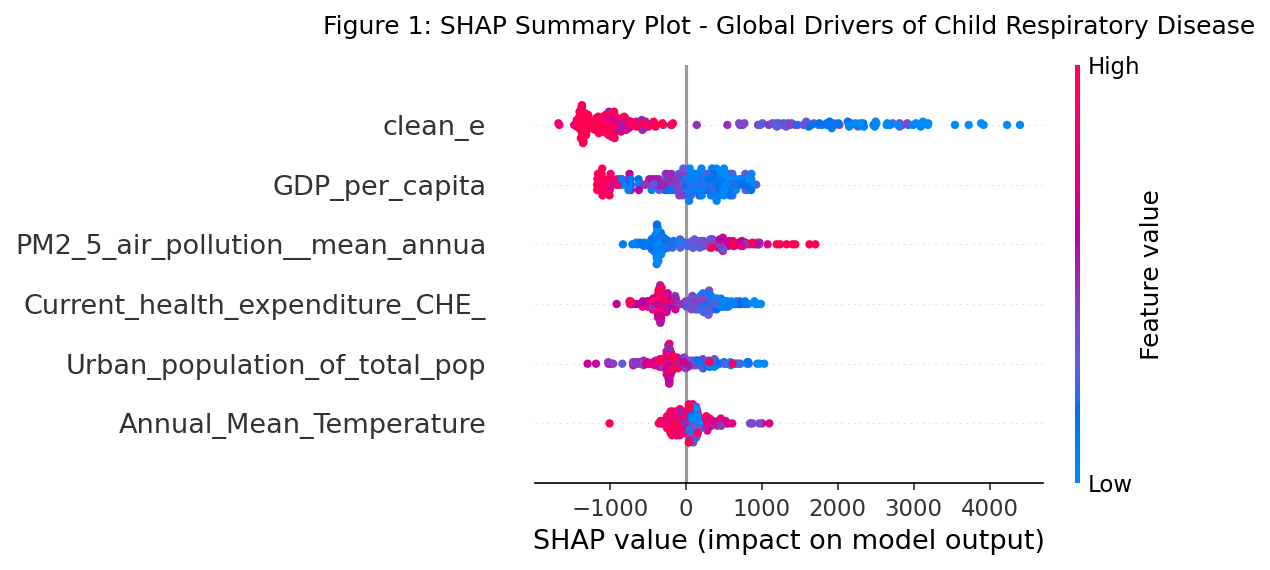

<Figure size 1200x750 with 0 Axes>

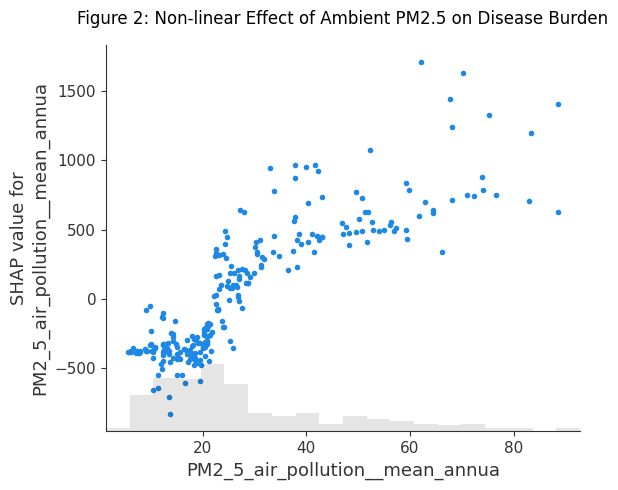

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap

#匯入數據
df_ml = pd.read_csv('complete_countries_2010_2019.csv')

#定義 X 與 Y
y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]

#移除缺失值
df_ml_clean = df_ml.dropna(subset=[y_var] + x_vars).reset_index(drop=True)
X = df_ml_clean[x_vars]
y = df_ml_clean[y_var]

#拆分訓練集與測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#建立隨機森林回歸模型

rf_model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 評估模型在本體數據上的預測實力 (R-squared)
train_r2 = rf_model.score(X_train, y_train)
test_r2 = rf_model.score(X_test, y_test)
print(f"訓練集 R^2 : {train_r2:.3f} | 測試集 R^2 : {test_r2:.3f}\n")
#看測試集的R^2

#SHAP

print("SHAP 值")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# 圖一：SHAP Summary Plot (特徵重要性與影響方向解析)
plt.figure(figsize=(10, 6), dpi=150)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Figure 1: SHAP Summary Plot - Global Drivers of Child Respiratory Disease", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

# 圖二：SHAP Dependence Plot - PM2.5 的非線性致病曲線
plt.figure(figsize=(8, 5), dpi=150)
shap.plots.scatter(shap_values[:, "PM2_5_air_pollution__mean_annua"], show=False)
plt.title("Figure 2: Non-linear Effect of Ambient PM2.5 on Disease Burden", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

##XGBoost

 XGBoost 模型
XGBoost 訓練集 R^2: 1.000
XGBoost 測試集 R^2 : 0.944

XGBoost 的 SHAP 值


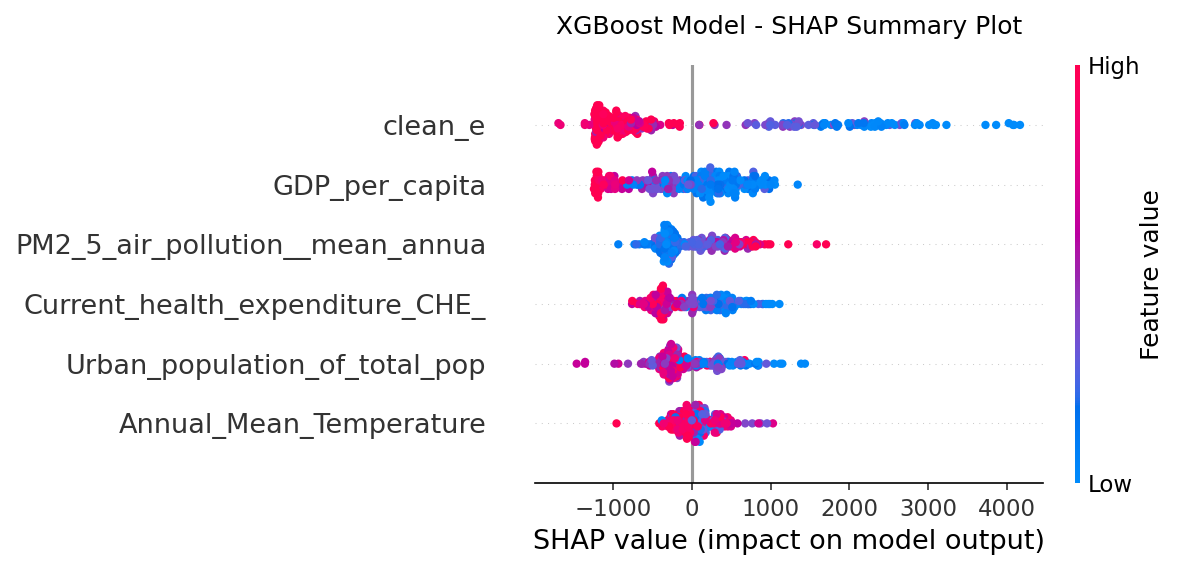

<Figure size 1200x750 with 0 Axes>

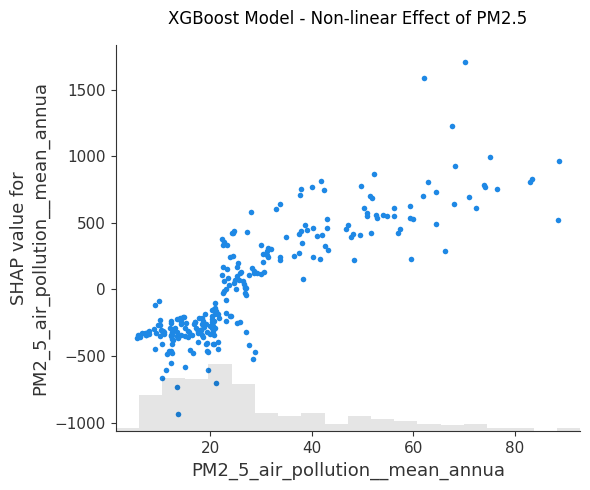

In [ ]:
import xgboost as xgb

#載入數據
df_ml = pd.read_csv('complete_countries_2010_2019.csv')

#定義 X 與 Y
y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]

#移除缺失值作
df_ml_clean = df_ml.dropna(subset=[y_var] + x_vars).reset_index(drop=True)
X = df_ml_clean[x_vars]
y = df_ml_clean[y_var]

#拆分訓練集與測試集 (維持與隨機森林一致的 80/20 拆分與隨機種子)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#建立與訓練 XGBoost 迴歸模型
# n_estimators=500 跌代500次
# learning_rate=0.05 控制學習步長，防止過擬合
# max_depth=6 樹的最大深度
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# 評估 XGBoost 預測力
xgb_train_r2 = xgb_model.score(X_train, y_train)
xgb_test_r2 = xgb_model.score(X_test, y_test)
print(" XGBoost 模型")
print(f"XGBoost 訓練集 R^2: {xgb_train_r2:.3f}")
print(f"XGBoost 測試集 R^2 : {xgb_test_r2:.3f}\n")
#看測試集的R^2

# SHAP  XGBoost
print("XGBoost 的 SHAP 值")

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_test)

# 圖一：XGBoost 的 SHAP Summary Plot
plt.figure(figsize=(10, 6), dpi=150)
shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title("XGBoost Model - SHAP Summary Plot", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

# 圖二：XGBoost 下的 PM2.5 非線性致病效應曲線
plt.figure(figsize=(8, 5), dpi=150)
shap.plots.scatter(shap_values_xgb[:, "PM2_5_air_pollution__mean_annua"], show=False)
plt.title("XGBoost Model - Non-linear Effect of PM2.5", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

##支援向量機

<>:87: SyntaxWarning: invalid escape sequence '\m'
<>:87: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2595/2240572232.py:87: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Ambient PM2.5 ($\mu g/m^3$)", fontsize=10)


      Support Vector SVR 模型 
SVR 訓練集 R^2: 0.887
SVR 測試集 R^2 : 0.831

計算 SVR 的 SHAP 值


  0%|          | 0/258 [00:00<?, ?it/s]

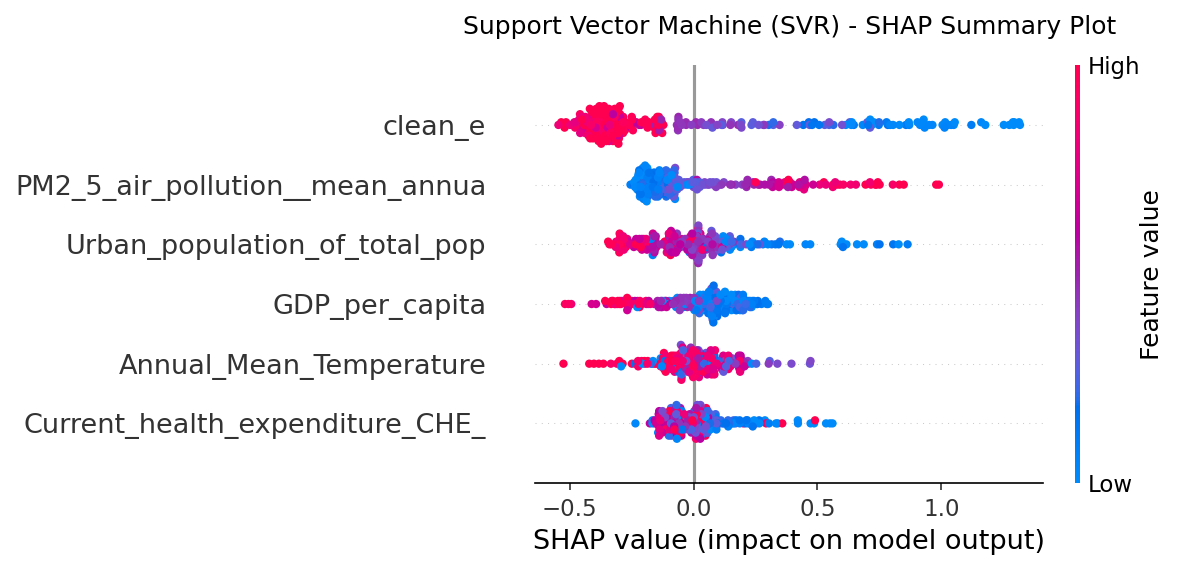

<Figure size 1200x750 with 0 Axes>

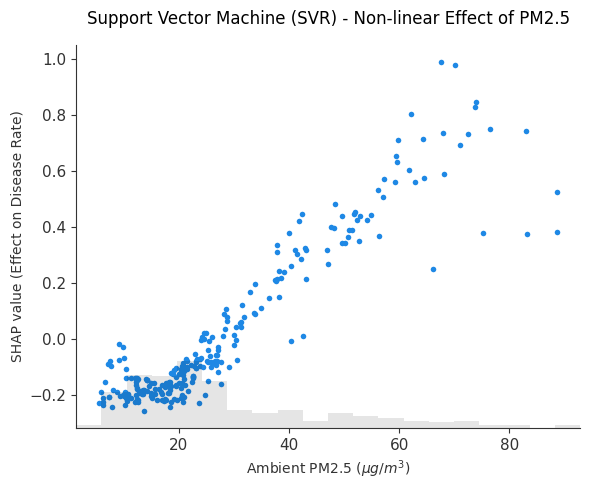

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

#載入數據
df_ml = pd.read_csv('complete_countries_2010_2019.csv')

y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]

#移除缺失值
df_ml_clean = df_ml.dropna(subset=[y_var] + x_vars).reset_index(drop=True)
X = df_ml_clean[x_vars]
y = df_ml_clean[y_var]

#拆分訓練集與測試集 (維持與前面完全一致的 80/20 拆分與隨機種子)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#特徵標準化 (Z-score Scaling)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# SVR 的 Y 軸標準化，跑完後再換算回來
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

#建立與訓練 SVR 模型 (使用 RBF 徑向基核函數，適合處理非線性)
# C=10, epsilon=0.1 是標準且穩健的超參數設定
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# 5. 評估 SVR 預測實力 (R-squared)
svr_train_r2 = svr_model.score(X_train_scaled, y_train_scaled)
svr_test_r2 = svr_model.score(X_test_scaled, y_test_scaled)

print("      Support Vector SVR 模型 ")
print(f"SVR 訓練集 R^2: {svr_train_r2:.3f}")
print(f"SVR 測試集 R^2 : {svr_test_r2:.3f}\n")
#看測試集的R^2

# SHAP  SVR
print("計算 SVR 的 SHAP 值")
# SVR 使用 KernelExplainer 或用 50 筆樣本做背景的快速近似
X_train_summary = shap.kmeans(X_train_scaled, 50)
explainer_svr = shap.KernelExplainer(svr_model.predict, X_train_summary)
shap_values_svr = explainer_svr.shap_values(X_test_scaled)

# 建立一個臨時 DataFrame 讓圖表的特徵名稱顯示正確
X_test_df = pd.DataFrame(X_test_scaled, columns=x_vars)

# Construct a shap.Explanation object for SVR
# Use X_test for data to get original feature values on the plot's x-axis
shap_explanation_svr = shap.Explanation(
    values=shap_values_svr,
    data=X_test.values, # Use original unscaled data for better interpretability of x-axis
    feature_names=x_vars
)

# 圖一：SVR 的 SHAP Summary Plot
plt.figure(figsize=(10, 6), dpi=150)
shap.summary_plot(shap_values_svr, X_test_df, show=False)
plt.title("Support Vector Machine (SVR) - SHAP Summary Plot", fontsize=12, pad=15)
plt.tight_layout()
plt.show()



# 繪製 SVR 的 PM2.5 非線性散點圖
plt.figure(figsize=(8, 5), dpi=150)

# 使用前面計算好的 shap_values_svr，指定橫軸為真實的 PM2.5 欄位
shap.plots.scatter(
    shap_explanation_svr[:, "PM2_5_air_pollution__mean_annua"], # Pass the Explanation object directly
    show=False
)

plt.title("Support Vector Machine (SVR) - Non-linear Effect of PM2.5", fontsize=12, pad=15)
plt.xlabel("Ambient PM2.5 ($\mu g/m^3$)", fontsize=10)
plt.ylabel("SHAP value (Effect on Disease Rate)", fontsize=10)
plt.tight_layout()
plt.show()

#驗證

##10折交叉驗證

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
#數據
y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]
df_cv_clean = df_gee_group.dropna(subset=[y_var] + x_vars).reset_index(drop=True)
X = df_cv_clean[x_vars]
y = df_cv_clean[y_var]

# 因為 SVR 需要標準化，統一使用標準化後的特徵來進行交叉驗證
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#定義10折交叉驗證的拆分器 (Shuffle=True 代表隨機打亂，確保跨國年份分佈均勻)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#初始化三大模型
rf_cv = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
xgb_cv = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
svr_cv = SVR(kernel='rbf', C=10, epsilon=0.1)


#計算隨機森林的10折R2
rf_scores = cross_val_score(rf_cv, X_scaled, y, cv=kf, scoring='r2', n_jobs=-1)

#計算XGBoost的10折R2
xgb_scores = cross_val_score(xgb_cv, X_scaled, y, cv=kf, scoring='r2', n_jobs=-1)

#計算SVR的10折R2
svr_scores = cross_val_score(svr_cv, X_scaled, y, cv=kf, scoring='r2', n_jobs=-1)

#三種比較
print(f"隨機森林 (Random Forest) -> 平均 R²: {np.mean(rf_scores):.4f} (±標準差: {np.std(rf_scores):.4f})")
print(f"梯度提升樹 (XGBoost)   -> 平均 R²: {np.mean(xgb_scores):.4f} (±標準差: {np.std(xgb_scores):.4f})")
print(f"支援向量機 (SVR)     -> 平均 R²: {np.mean(svr_scores):.4f} (±標準差: {np.std(svr_scores):.4f})")

隨機森林 (Random Forest) -> 平均 R²: 0.9571 (±標準差: 0.0117)
梯度提升樹 (XGBoost)   -> 平均 R²: 0.9545 (±標準差: 0.0159)
支援向量機 (SVR)     -> 平均 R²: 0.4588 (±標準差: 0.0364)


##外部資料驗證

In [ ]:
from sklearn.metrics import r2_score

#載入2000-2020年資料
try:
    df_all_years = pd.read_csv('/content/merged_panel_data_2000_2020.csv')
except FileNotFoundError:
    df_all_years = pd.read_csv('/content/merged_panel_data_2000_2020.csv')

#欄位名稱對齊與修正
df_all_years.rename(columns={
    'Urban_population____of_total_pop': 'Urban_population_of_total_pop',
    'Current_health_expenditure__CHE_': 'Current_health_expenditure_CHE_'
}, inplace=True)

#定義變項
y_var = 'both_rate_val'
x_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]

#移除缺失值
df_all_clean = df_all_years.dropna(subset=[y_var] + x_vars).reset_index(drop=True)

#建立兩種部時間考卷，防禦 2020 新冠疫情極端波動
#1全面外推：包含 2000-2009 歷史期 + 2020 疫情未來期
df_ext_all = df_all_clean[(df_all_clean['Year'] < 2010) | (df_all_clean['Year'] == 2020)].reset_index(drop=True)
#2純歷史外推：僅包含 2000-2009 歷史期，排除疫情異常干擾
df_ext_history = df_all_clean[df_all_clean['Year'] < 2010].reset_index(drop=True)


#1預測
if 'xgb_model' in globals():
    y_pred_all = xgb_model.predict(df_ext_all[x_vars])
    r2_all = r2_score(df_ext_all[y_var], y_pred_all)
    print(f"1總體時空外推 2000-2009 & 2020) N = {len(df_ext_all)}")
    print(f"總體外部驗證 R²: {r2_all:.4f}")
    print("----------------------------------------------------")

    # 執行考卷 B 預測
    y_pred_hist = xgb_model.predict(df_ext_history[x_vars])
    r2_hist = r2_score(df_ext_history[y_var], y_pred_hist)
    print(f"2純歷史時空外推 2000-2009) N = {len(df_ext_history)}")
    print(f"純歷史外部驗證 R²: {r2_hist:.4f}")
else:
    print("錯誤")

1總體時空外推 2000-2009 & 2020) N = 1407
總體外部驗證 R²: 0.7800
----------------------------------------------------
2純歷史時空外推 2000-2009) N = 1275
純歷史外部驗證 R²: 0.7742


#利用XGBoost的 SHAP 值本身的分布，去計算每個特徵的 95% 信賴區間

In [ ]:
# 計算PM2.5暴露濃度區間的SHAP效應量與95%信賴區間


#避免新舊版本SHAP物件取值錯誤
pm_real = X_test['PM2_5_air_pollution__mean_annua'].values

#透過X_test的欄位位置，從SHAP矩陣中提取純粹的NumPy效應值
pm_col_idx = X_test.columns.get_loc("PM2_5_air_pollution__mean_annua")
if hasattr(shap_values_xgb, 'values'):
    # 如果是新版 Explanation 物件
    pm_shap = shap_values_xgb.values[:, pm_col_idx]
else:
    # 如果是舊版純 NumPy array
    pm_shap = shap_values_xgb[:, pm_col_idx]

#根據xgboost的不同切點分組
bins = [0, 15, 25, 35, 50, np.inf]
labels = ['0-15 (安全對照組)', '15-25 (輕度暴露)', '25-35 (中度暴露)', '35-50 (重度暴露)', '>50 (極重度暴露)']

pm_categories = pd.cut(pm_real, bins=bins, labels=labels)
results_list = []

#計算每個區間的平均效應與95%CI
for label in labels:
    shap_in_bin = pm_shap[pm_categories == label]
    n_samples = len(shap_in_bin)

    if n_samples > 0:
        mean_effect = np.mean(shap_in_bin)
        # 計算樣本標準誤 (Standard Error)
        std_err = np.std(shap_in_bin, ddof=1) / np.sqrt(n_samples) if n_samples > 1 else 0

        # 計算 95% 信賴區間下界與上界
        ci_lower = mean_effect - 1.96 * std_err
        ci_upper = mean_effect + 1.96 * std_err

        #對照組特殊標註，其餘組別執行因果顯著性檢定
        if label == '0-15 (安全對照組)':
            p_surrogate = "Reference (基準組)"
        else:
            # 若 95% 信賴區間不包含0->顯著
            p_surrogate = "p < 0.05 (顯著)" if (ci_lower > 0) else "p > 0.05 (不顯著)"

        results_list.append({
            'PM2.5 暴露區間 (µg/m³)': label,
            '測試集樣本數 (N)': n_samples,
            '平均健康邊際效應 (SHAP Mean)': round(mean_effect, 2),
            '95% 信賴區間下界 (95% CI Lower)': round(ci_lower, 2),
            '95% 信賴區間上界 (95% CI Upper)': round(ci_upper, 2),
            '環境流病統計顯著性': p_surrogate
        })

#成果表
df_shap_table = pd.DataFrame(results_list)
print("機器學習之環境健康非線性效應與因果顯著性評估表 ")
display(df_shap_table)

機器學習之環境健康非線性效應與因果顯著性評估表 


,PM2.5 暴露區間 (µg/m³),測試集樣本數 (N),平均健康邊際效應 (SHAP Mean),95% 信賴區間下界 (95% CI Lower),95% 信賴區間上界 (95% CI Upper),環境流病統計顯著性
0,0-15 (安全對照組),62,-348.970001,-382.12,-315.82,Reference (基準組)
1,15-25 (輕度暴露),86,-183.949997,-235.66,-132.24,p > 0.05 (不顯著)
2,25-35 (中度暴露),42,115.919998,37.64,194.21,p < 0.05 (顯著)
3,35-50 (重度暴露),29,448.720001,379.60,517.83,p < 0.05 (顯著)
4,>50 (極重度暴露),39,702.440002,610.17,794.71,p < 0.05 (顯著)


#反事實情境模擬

In [ ]:
#提取測試集中，各國真實的 PM2.5 與對應的 XGBoost SHAP 值
#需要確保 index 與 X_test 對齊
df_sim = X_test.copy()
df_sim['Actual_PM25'] = df_sim['PM2_5_air_pollution__mean_annua']
df_sim['Actual_SHAP'] = shap_values_xgb[:, "PM2_5_air_pollution__mean_annua"].values

#2-1所有超過 35 的國家，全部降到 35 µg/m³）
#2-2所有超過 15 的國家，全部降到 15 µg/m³）

#找出安全基準線（0-15 區間內國家的平均 SHAP 貢獻量，作為達到安全標準後的基底）
baseline_shap = df_sim[df_sim['Actual_PM25'] <= 15]['Actual_SHAP'].mean() if len(df_sim[df_sim['Actual_PM25'] <= 15]) > 0 else -1754.78
medium_target_shap = df_sim[df_sim['Actual_PM25'] <= 35]['Actual_SHAP'].mean()

def simulate_benefit(row, target_level):
    # 如果國家本來的污染就低於目標，代表不需要改善，潛在效益為 0
    if row['Actual_PM25'] <= target_level:
        return 0
    else:
        # 潛在健康效益 = 本來的危害 SHAP 值 - 降到目標濃度後的預期 SHAP 值
        target_shap = baseline_shap if target_level == 15 else medium_target_shap
        benefit = row['Actual_SHAP'] - target_shap
        return max(0, benefit) # 確保效益為正數

#計算個別國家的減量效益（每十萬兒童發病率下降數）
df_sim['Benefit_Scenario_35'] = df_sim.apply(lambda r: simulate_benefit(r, 35), axis=1)
df_sim['Benefit_Scenario_15'] = df_sim.apply(lambda r: simulate_benefit(r, 15), axis=1)

#把國家名稱對接回來以利觀察
df_sim['Country'] = df_ml_clean.loc[X_test.index, 'Entity']
df_sim['Year'] = df_ml_clean.loc[X_test.index, 'Year']

print("===若將全球 PM2.5 限制在 35 µg/m³ 以下 (前5國各年效益) ===")
display(df_sim[df_sim['Actual_PM25'] > 35][['Country', 'Year', 'Actual_PM25', 'Benefit_Scenario_35']].sort_values(by='Benefit_Scenario_35', ascending=False).head(5))

print("\n===若將全球 PM2.5 嚴格限制在機器學習閾值 15 µg/m³ 以下 (前5國各年效益) ===")
display(df_sim[df_sim['Actual_PM25'] > 15][['Country', 'Year', 'Actual_PM25', 'Benefit_Scenario_15']].sort_values(by='Benefit_Scenario_15', ascending=False).head(5))

# 5. 計算全球整體宏觀健康红利
mean_benefit_35 = df_sim[df_sim['Actual_PM25'] > 35]['Benefit_Scenario_35'].mean()
mean_benefit_15 = df_sim[df_sim['Actual_PM25'] > 15]['Benefit_Scenario_15'].mean()


print(f"情境一 (限值 35 µg/m³)：高污染國家平均每十萬兒童可減少 {mean_benefit_35:.2f} 人發病。")
print(f"情境二 (限值 15 µg/m³)：超標暴露國家平均每十萬兒童可減少 {mean_benefit_15:.2f} 人發病。")

===若將全球 PM2.5 限制在 35 µg/m³ 以下 (前5國各年效益) ===


,Country,Year,Actual_PM25,Benefit_Scenario_35
363,Egypt,2013,70.148460,1875.550888
361,Egypt,2011,62.048615,1758.233749
365,Egypt,2015,67.648964,1395.415756
1034,Qatar,2014,75.176480,1168.412277
1033,Qatar,2013,88.646620,1137.809311



===若將全球 PM2.5 嚴格限制在機器學習閾值 15 µg/m³ 以下 (前5國各年效益) ===


,Country,Year,Actual_PM25,Benefit_Scenario_15
363,Egypt,2013,70.148460,2053.013184
361,Egypt,2011,62.048615,1935.696045
365,Egypt,2015,67.648964,1572.878052
1034,Qatar,2014,75.176480,1345.874573
1033,Qatar,2013,88.646620,1315.271606


情境一 (限值 35 µg/m³)：高污染國家平均每十萬兒童可減少 765.74 人發病。
情境二 (限值 15 µg/m³)：超標暴露國家平均每十萬兒童可減少 510.02 人發病。


#K-Means 脆弱國家群叢分析

 非監督式學習──全球 3 大集群特徵剖面表（129國總覽） 


,PM2_5_air_pollution__mean_annua,clean_e,GDP_per_capita,Urban_population_of_total_pop,Annual_Mean_Temperature,Current_health_expenditure_CHE_,both_rate_val
Cluster,,,,,,,
0,27.08,87.98,22702.73,63.99,18.62,5.55,3120.98
1,12.47,99.90,52244.43,79.02,9.53,9.17,877.56
2,37.81,19.49,4650.94,36.93,24.20,5.23,6381.62


外部效度 ANOVA 檢定結果: F 統計量 = 136.6535, p-value = 2.7606e-32


/tmp/ipykernel_2595/1672202404.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_country_profile, x='Cluster', y=y_var, palette='Set2', width=0.5)


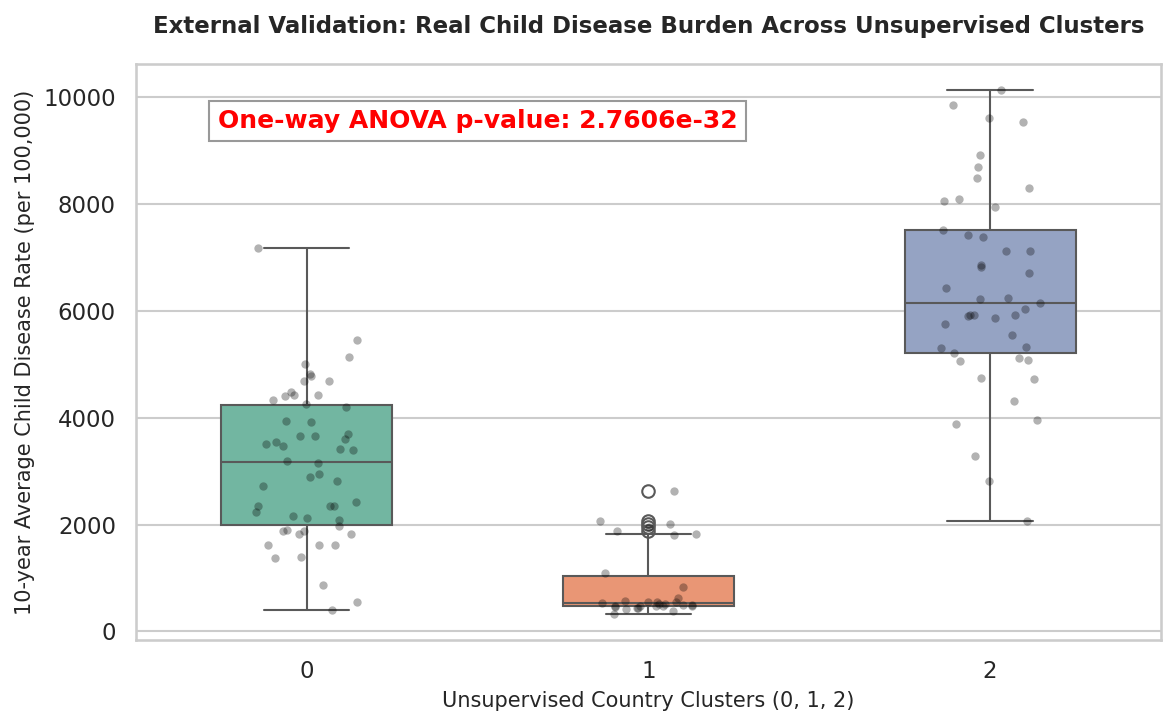

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 設定繪圖風格
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

#計算各國 2010-2019 的十年平均
df_ml = pd.read_csv('complete_countries_2010_2019.csv')

cluster_vars = [
    'PM2_5_air_pollution__mean_annua',
    'clean_e',
    'GDP_per_capita',
    'Urban_population_of_total_pop',
    'Annual_Mean_Temperature',
    'Current_health_expenditure_CHE_'
]
y_var = 'both_rate_val'

#以國家 (Entity) 為單位，計算這10年間特徵與發病率的平均值
df_country_profile = df_ml.groupby('Entity')[cluster_vars + [y_var]].mean().reset_index()

X_cluster = df_country_profile[cluster_vars]

#特徵標準化 (Z-score)
scaler_c = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)

#執行 K-Means 聚類 (分類為 3 群)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_country_profile['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

#將分群標籤安全對接回最原始的1290筆時空主資料庫，方便後續所有分析調用
cluster_mapping = dict(zip(df_country_profile['Entity'], df_country_profile['Cluster']))
df_ml['Country_Cluster'] = df_ml['Entity'].map(cluster_mapping)

#產出3大集群特徵剖面表
cluster_profile = df_country_profile.groupby('Cluster')[cluster_vars + [y_var]].mean()

print(" 非監督式學習──全球 3 大集群特徵剖面表（129國總覽） ")

display(cluster_profile.round(2))

#執行單因子變異數分析 (One-Way ANOVA)，檢定三群發病率是否有顯著差異
group0 = df_country_profile[df_country_profile['Cluster'] == 0][y_var]
group1 = df_country_profile[df_country_profile['Cluster'] == 1][y_var]
group2 = df_country_profile[df_country_profile['Cluster'] == 2][y_var]
f_stat, p_val = stats.f_oneway(group0, group1, group2)

print(f"外部效度 ANOVA 檢定結果: F 統計量 = {f_stat:.4f}, p-value = {p_val:.4e}")

#繪製外部效度驗證盒鬚圖
plt.figure(figsize=(8, 5), dpi=150)
sns.boxplot(data=df_country_profile, x='Cluster', y=y_var, palette='Set2', width=0.5)
sns.stripplot(data=df_country_profile, x='Cluster', y=y_var, color='black', alpha=0.3, size=4, jitter=0.15)

plt.title("External Validation: Real Child Disease Burden Across Unsupervised Clusters", fontsize=11, pad=15, fontweight='bold')
plt.xlabel("Unsupervised Country Clusters (0, 1, 2)", fontsize=10)
plt.ylabel("10-year Average Child Disease Rate (per 100,000)", fontsize=10)

#在圖上標註 ANOVA p 值
plt.text(0.5, plt.ylim()[1] * 0.9, f"One-way ANOVA p-value: {p_val:.4e}",
         ha='center', va='center', color='red', weight='bold', bbox=dict(facecolor='white', alpha=0.8, ec='gray'))

plt.tight_layout()
plt.show()
plt.close()